In [31]:
!pip install gensim

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd

test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ELEC2/LAB3: Word2Vec and Multiclass Classification/test.csv')
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ELEC2/LAB3: Word2Vec and Multiclass Classification/train.csv')
valid_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ELEC2/LAB3: Word2Vec and Multiclass Classification/val.csv')

print(test_df.head)
print(train_df.head)
print(valid_df.head)

<bound method NDFrame.head of                                                  review  sentiment
0     okay naman yung product, cute. sobrang tagal l...          4
1     maliit ang size l dapat xl kunin mo if 33 size...          2
2     the premium meats doesn't taste premium at all...          1
3     ang nakalagay ay 10m pero 5 meters lang pala a...          1
4     as usual ang ganda pa din. thanks seller and k...          3
...                                                 ...        ...
2097  receive kuna po ung order ko.super ganda po tl...          3
2098  medyo dismayado ako kc order ko is black masca...          1
2099  bukod ang tagal dumating e iba iba p ung foam ...          1
2100  fine it's loose and yung tela nya is manipis t...          2
2101           excellent bilis dumating. thanks seller.          3

[2102 rows x 2 columns]>
<bound method NDFrame.head of                                                  review  sentiment
0     tumatagal naman sya thank you seller 

In [34]:
print(test_df.shape)
print(train_df.shape)
print(valid_df.shape)

(2102, 2)
(6306, 2)
(2102, 2)


In [35]:
STUDENT_NUMBER = 2023172283

In [36]:
# Preprocessing and Word2Vec
import re
from gensim.models import Word2Vec

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

train_sentences = train_df['review'].apply(simple_tokenizer).tolist()
val_sentences = valid_df['review'].apply(simple_tokenizer).tolist()
test_sentences = test_df['review'].apply(simple_tokenizer).tolist()

# Training Word2Vec
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=300,
    window=7,
    min_count=2,
    sg=1,
    workers=4,
    seed=STUDENT_NUMBER
)

# Function to average word vectors for a sentence
def get_sentence_vector(sentence, model):
    # Filter out words not in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        # Return zero vector if no words found in vocab
        return np.zeros(model.vector_size)

# Vectorize all datasets
X_train = np.array([get_sentence_vector(s, w2v_model) for s in train_sentences])
X_val = np.array([get_sentence_vector(s, w2v_model) for s in val_sentences])
X_test = np.array([get_sentence_vector(s, w2v_model) for s in test_sentences])

y_train = train_df['sentiment']
y_val = valid_df['sentiment']
y_test = test_df['sentiment']

print("Data Vectorization complete.")

Data Vectorization complete.


/tmp/ipython-input-3334227561.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=train_df, palette='viridis')


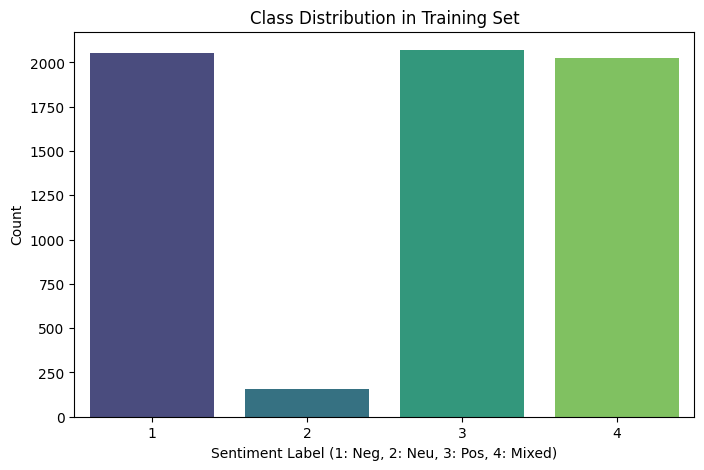

Generating Bigram Analysis...
--- Top Phrases in NEGATIVE Reviews ---


/tmp/ipython-input-3334227561.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Phrase', data=df_ngram, palette='viridis')


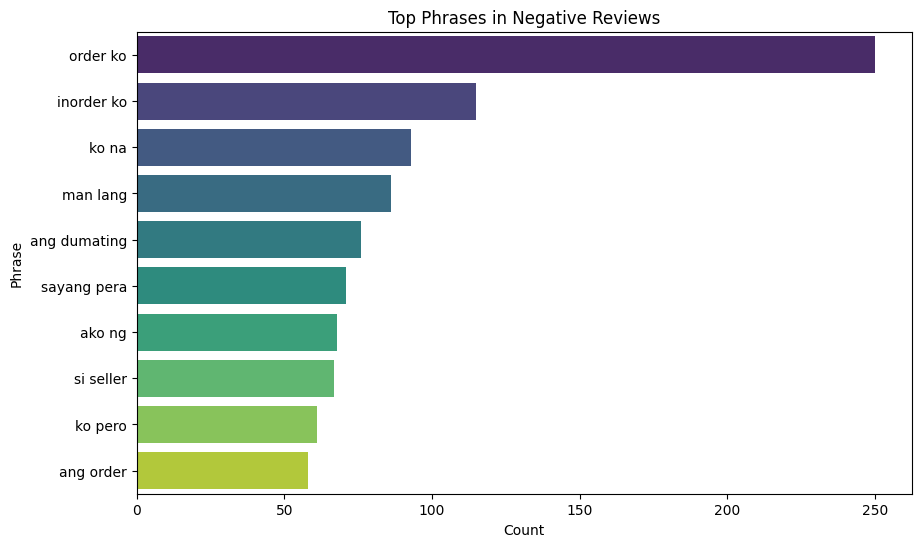

--- Top Phrases in MIXED Reviews ---


/tmp/ipython-input-3334227561.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Phrase', data=df_ngram, palette='viridis')


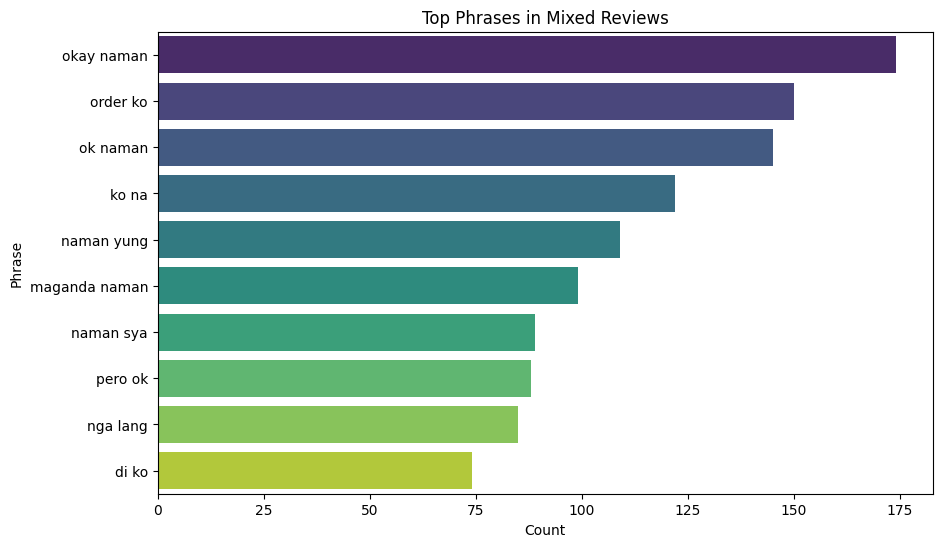

Generating t-SNE Plot (This might take a moment)...


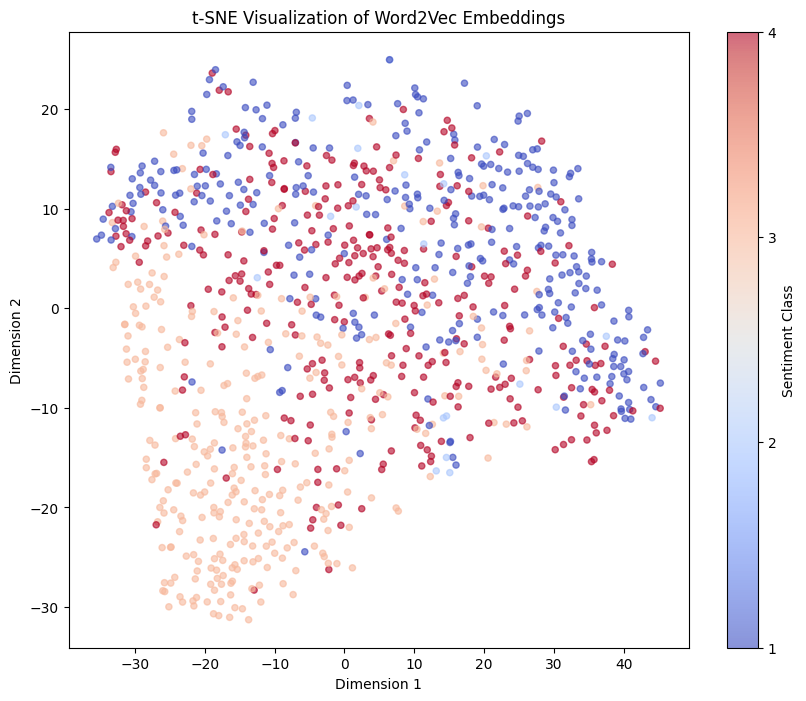

In [37]:
# EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE

# Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Sentiment Label (1: Neg, 2: Neu, 3: Pos, 4: Mixed)')
plt.ylabel('Count')
plt.show()

# Set up the figure area
fig_size = (10, 6)

# Bigrams (Phrases) per Class ---
print("Generating Bigram Analysis...")
def plot_top_ngrams(corpus, n=2, title="Top Bigrams"):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:10]

    # Plot
    df_ngram = pd.DataFrame(words_freq, columns=['Phrase', 'Count'])
    plt.figure(figsize=fig_size)
    sns.barplot(x='Count', y='Phrase', data=df_ngram, palette='viridis')
    plt.title(title)
    plt.show()

# Plot Bigrams for Negative Reviews
print("--- Top Phrases in NEGATIVE Reviews ---")
plot_top_ngrams(train_df[train_df['sentiment']==1]['review'], n=2, title="Top Phrases in Negative Reviews")

# Plot Bigrams for Mixed Reviews
print("--- Top Phrases in MIXED Reviews ---")
plot_top_ngrams(train_df[train_df['sentiment']==4]['review'], n=2, title="Top Phrases in Mixed Reviews")

# t-SNE Vector Visualization
print("Generating t-SNE Plot (This might take a moment)...")

# Take a random subset of 1,000 samples to keep it fast and readable
subset_indices = np.random.choice(len(X_train), size=1000, replace=False)
X_subset = X_train[subset_indices]
y_subset = y_train.iloc[subset_indices]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_subset)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_subset, cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(scatter, ticks=[1, 2, 3, 4], label='Sentiment Class')
plt.title('t-SNE Visualization of Word2Vec Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [38]:
# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=STUDENT_NUMBER, max_iter=1000),
    "SVM (Linear SVC)": SVC(kernel='linear', random_state=STUDENT_NUMBER),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=STUDENT_NUMBER)
}

best_model_name = ""
best_acc = 0
best_model = None
results = {}

# Train and Evaluate on Validation Set
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    results[name] = acc
    print(f"  -> Validation Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

print(f"\nBest Performing Model: {best_model_name} ({best_acc:.4f})")


Training Logistic Regression...
  -> Validation Accuracy: 0.7536
Training SVM (Linear SVC)...
  -> Validation Accuracy: 0.7593
Training Random Forest...
  -> Validation Accuracy: 0.7464

Best Performing Model: SVM (Linear SVC) (0.7593)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.74      0.79      0.77       660
           2       0.00      0.00      0.00        55
           3       0.86      0.81      0.83       686
           4       0.68      0.72      0.70       701

    accuracy                           0.75      2102
   macro avg       0.57      0.58      0.57      2102
weighted avg       0.74      0.75      0.74      2102



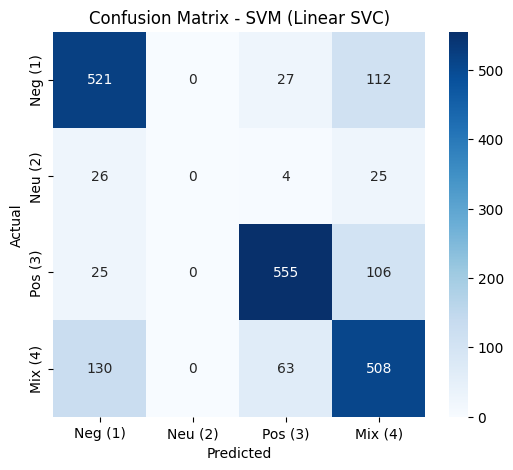

In [39]:
# FINAL ANALYSIS: Test Set

test_preds = best_model.predict(X_test)
print(classification_report(y_test, test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg (1)', 'Neu (2)', 'Pos (3)', 'Mix (4)'],
            yticklabels=['Neg (1)', 'Neu (2)', 'Pos (3)', 'Mix (4)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()
